In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("abalone.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [3]:
print(df.head())

  Sex  Length  Diameter  Height  Whole weight  Shucked weight  Viscera weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell weight  Rings  
0         0.150     15  
1         0.070      7  
2         0.210      9  
3         0.155     10  
4         0.055      7  


In [4]:
print(df.tail())

     Sex  Length  Diameter  Height  Whole weight  Shucked weight  \
4172   F   0.565     0.450   0.165        0.8870          0.3700   
4173   M   0.590     0.440   0.135        0.9660          0.4390   
4174   M   0.600     0.475   0.205        1.1760          0.5255   
4175   F   0.625     0.485   0.150        1.0945          0.5310   
4176   M   0.710     0.555   0.195        1.9485          0.9455   

      Viscera weight  Shell weight  Rings  
4172          0.2390        0.2490     11  
4173          0.2145        0.2605     10  
4174          0.2875        0.3080      9  
4175          0.2610        0.2960     10  
4176          0.3765        0.4950     12  


In [5]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


Text(0.5, 1.0, 'Abalone Dataset')

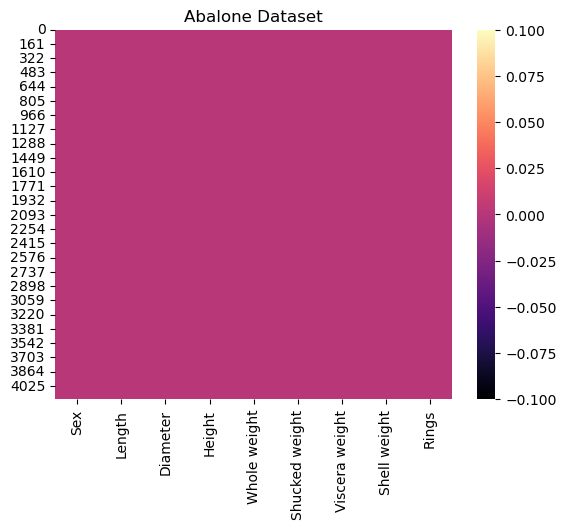

In [6]:
sb.heatmap(df.isnull(), cmap = 'magma')
plt.title("Abalone Dataset")


In [7]:
df.duplicated().sum()

np.int64(0)

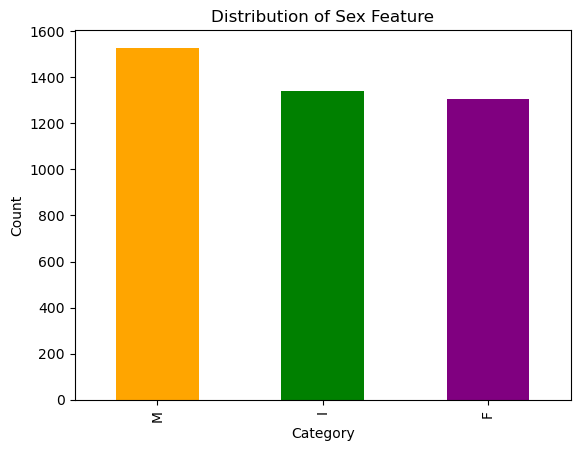

In [8]:
df['Sex'].value_counts().plot(kind='bar', color=['orange', 'green', 'purple'])
plt.title('Distribution of Sex Feature')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

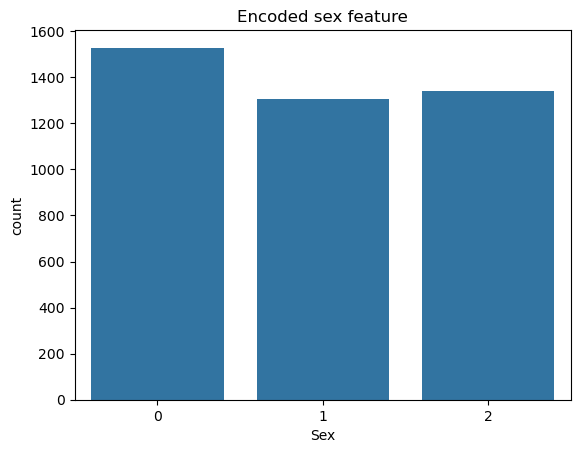

In [9]:
df['Sex'] = df['Sex'].map({'M':0, 'F':1, 'I':2})
sb.countplot(x='Sex', data = df)
plt.title('Encoded sex feature')
plt.show()

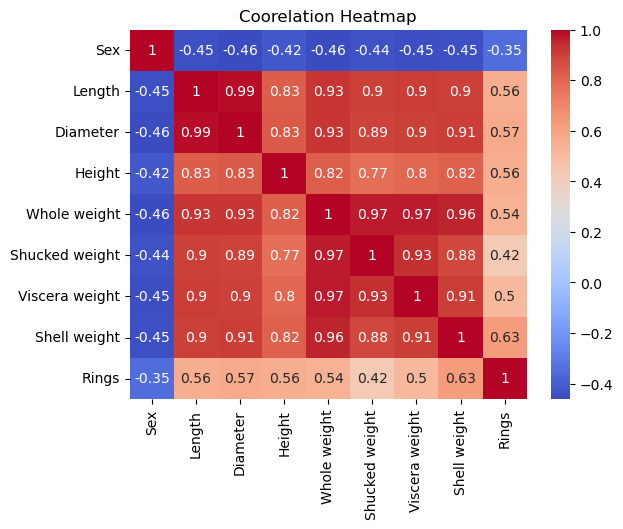

In [10]:
corr = df.corr()
sb.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('Coorelation Heatmap')
plt.show()

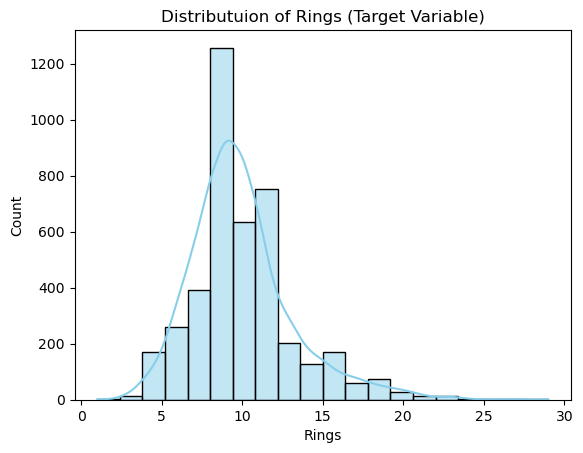

In [11]:
sb.histplot(df['Rings'], bins=20, kde=True, color = 'skyblue')
plt.title('Distributuion of Rings (Target Variable)')
plt.show()

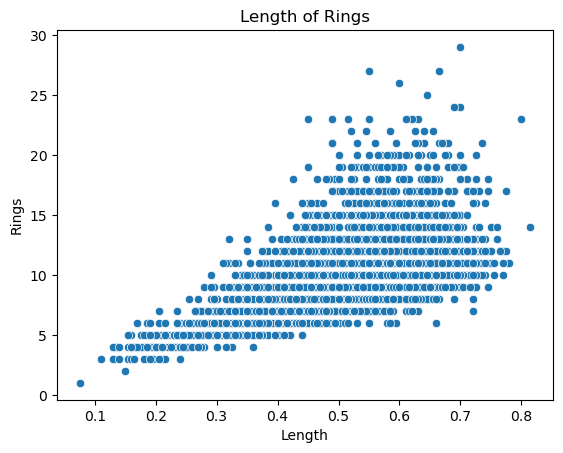

In [12]:
sb.scatterplot(x='Length', y='Rings', data=df)
plt.title('Length of Rings')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
x = df.drop('Rings', axis=1)
y = df['Rings']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [21]:
# standardscaler - standardization is used to normalize features so that they have the mean = 0 and standard deviation = 1
# -> why: because it wants to break all features to the same scale
# z = (x - u)/sigma(p), whare z = standard scaler, u = mean, sigma = standard deviation 

# fit is basically learn the mean and standard deviation and transform, we prevent data leakage by doing this
#  It improves model performance and faster conversion, and is used for many ML models

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [15]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42))
]

results = {}
for name, model in models:
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = r2
    print(f'{name}: MSE = {mse:.2f}, R2 = {r2:.2f}')

Linear Regression: MSE = 4.95, R2 = 0.54
Ridge Regression: MSE = 4.99, R2 = 0.54
Decision Tree: MSE = 9.02, R2 = 0.17
Random Forest: MSE = 5.07, R2 = 0.53


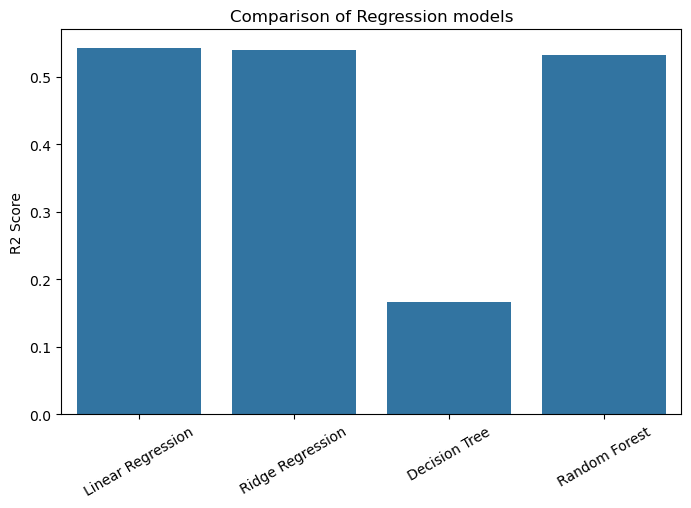

In [16]:
plt.figure(figsize = (8, 5))
sb.barplot(x = list(results.keys()), y = list(results.values()))
plt.title('Comparison of Regression models')
plt.ylabel("R2 Score")
plt.xticks(rotation = 30)
plt.show()

In [17]:
dtr = DecisionTreeRegressor()
dtr.fit(x_train, y_train)
y_pred = dtr.predict(x_test)
print('Decision Tree MSE: ', mean_squared_error(y_test, y_pred))
print('Decision Tree R2: ', r2_score(y_test, y_pred))

Decision Tree MSE:  9.41866028708134
Decision Tree R2:  0.12993279137834768


In [18]:
rf = RandomForestRegressor()
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
print('Random Forest MSE: ', mean_squared_error(y_test, y_pred))
print('Random Forest R2: ', r2_score(y_test, y_pred))

Random Forest MSE:  5.033096411483255
Random Forest R2:  0.5350578519676179


In [19]:
def prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight):
    features = np.array([[Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight]])
    pred = dtr.predict(features).reshape(1, -1)
    return pred[0]

In [22]:
#  Example for testing 

Sex = 3
Length = 0.4
Diameter = 0.32
Height = 0.25
Whole_weight = 1.5
Shucked_weight = 0.8
Viscera_weight = 0.9
Shell_weight = 0.9

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [18.]


C:\Users\singh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [23]:
Sex = 2
Length = 0.6
Diameter = 0.45
Height = 0.15
Whole_weight = 1.2
Shucked_weight = 0.6
Viscera_weight = 0.3
Shell_weight = 0.4

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [16.]


C:\Users\singh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [25]:
import pickle

# Save the model
with open("abalone_model.pkl", "wb") as f:
    pickle.dump(dtr, f)

# Save the scaler too (if you used StandardScaler)
with open("scaler.pkl", "wb") as f:
    pickle.dump(sc, f)

print("Model saved!")


Model saved!
